# PROYECTO: EDA con Python
## Entrega correspondiente al módulo "Python for data" del *Máster en Data & Analytics*

### BLOQUE 1: Importación y Configuración Inicial
Configuramos las librerías principales y ajustes necesarios para el análisis.

In [1]:
# =============================================================================
# BLOQUE 1: IMPORTACIÓN Y CONFIGURACIÓN INICIAL
# =============================================================================
# Esta celda establece el entorno de trabajo para el análisis exploratorio.
# Debe ejecutarse PRIMERA al abrir el notebook para garantizar disponibilidad
# de todas las dependencias y configuraciones.
#
# SECCIONES:
# 1.1 Librerías estándar de ciencia de datos
# 1.2 Configuración visual (pandas display + matplotlib)
# 1.3 Configuración de rutas para imports locales
# 1.4 Importación de módulos propios del proyecto
# =============================================================================

# -----------------------------------------------------------------------------
# 1.1 LIBRERÍAS PRINCIPALES
# -----------------------------------------------------------------------------
# io: Manejo de buffers en memoria (usado por DualOutput)
# sys: Manipulación del path de Python para imports locales
# pandas/numpy: Manipulación y análisis de datos tabulares
# matplotlib/seaborn: Visualización estadística
# datetime: Timestamps para métricas de rendimiento
import io
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# -----------------------------------------------------------------------------
# 1.2 CONFIGURACIÓN VISUAL
# -----------------------------------------------------------------------------
# Estas opciones optimizan la visualización de DataFrames en Jupyter:
# - max_columns=None: Muestra TODAS las columnas sin truncar
# - max_rows=None: Muestra TODAS las filas (cuidado con datasets grandes)
# - max_colwidth=None: No trunca contenido de celdas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# %matplotlib inline: Renderiza gráficos directamente en el notebook
# --- ESTILO VISUAL IGUAL QUE EN GITHUB ---
%matplotlib inline 
plt.style.use('seaborn-v0_8-darkgrid')  # Fondo gris y grillas como en el repo original
sns.set_palette("husl")  # Paleta de colores consistente
print("✓ Configuraciones visuales aplicadas")

# -----------------------------------------------------------------------------
# 1.3 CONFIGURACIÓN DE IMPORTS LOCALES
# -----------------------------------------------------------------------------
# PROBLEMA: Jupyter ejecuta desde notebooks/, pero los módulos están en src/
# SOLUCIÓN: Añadir la raíz del proyecto al sys.path
#
# Estructura esperada:
#   EDA_Marketing_Bancario/        ← project_root
#   ├── notebooks/                 ← os.getcwd() cuando se ejecuta el notebook
#   │   └── 01_EDA_Analisis.ipynb
#   └── src/                       ← módulos a importar
#       ├── __init__.py
#       ├── analisis_exploratorio.py
#       ├── cleaning_campaing.py
#       ├── data_cleaning.py
#       ├── pipeline.py
#       └── plotting.py
import os
project_root = os.path.dirname(os.getcwd())  # Sube un nivel desde notebooks/
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"✓ Ruta añadida al path: {project_root}")

# -----------------------------------------------------------------------------
# 1.4 MÓDULOS PROPIOS DEL PROYECTO
# -----------------------------------------------------------------------------
# Estos módulos contienen funciones reutilizables desarrolladas para este EDA:
# - analisis_exploratorio (ae): Funciones de reporting y tasas de conversión
# - data_cleaning (dc): Funciones de limpieza y transformación
# - cleaning_campaing (cc): Limpieza específica del dataset de campañas
# - plotting: Funciones de visualización (histogramas, barras, heatmaps, boxplots)
#
# NOTA SOBRE pipeline.py:
# ----------------------
# pipeline.py NO se importa como módulo aquí. Se ejecuta como script independiente
# usando %run src/pipeline.py en la celda de carga de datos. Razones:
# 1. No exporta funciones que se usen después en el notebook
# 2. Su propósito es ejecutar el ETL completo (cargar → limpiar → guardar CSVs)
# 3. Una vez ejecutado, el notebook carga los CSVs resultantes con pd.read_csv()
# 4. Si se importara (import src.pipeline), el ETL se ejecutaría automáticamente
#    al importar porque el código no está envuelto en if __name__ == '__main__'
#
# Flujo actual:
#   1: Importar módulos (ae, dc, cc, plotting) ← funciones reutilizables
#   2: %run src/pipeline.py                    ← ejecuta ETL, genera CSVs
#   3: pd.read_csv('df_perfil_cliente.csv')    ← carga resultado del pipeline
#
# El bloque try/except permite continuar si hay errores de import,
# mostrando el error específico para debugging.
try:
    import src.analisis_exploratorio as ae
    import src.data_cleaning as dc
    import src.cleaning_campaing as cc
    import src.plotting as pl
    print("✓ Módulos importados: analisis_exploratorio, data_cleaning, cleaning_campaing, plotting")
except ImportError as e:
    print(f"⚠ Error en imports: {e}")
    print("  → Verificar que los archivos existen en src/")
    print("  → Verificar que src/__init__.py existe")

✓ Configuraciones visuales aplicadas
✓ Ruta añadida al path: g:\Mi unidad\FP_DAM _DATA\1. MASTER Data & Analytics\EDA_Marketing_Bancario
✓ Módulos importados: analisis_exploratorio, data_cleaning, cleaning_campaing, plotting


In [2]:
# =============================================================================
# BLOQUE 1.5: UTILIDADES PERSONALIZADAS
# =============================================================================
# Este bloque define clases y funciones auxiliares reutilizables específicas
# para el análisis exploratorio de datos en notebooks Jupyter.
# Se mantienen aquí (en lugar de en módulos externos) por las siguientes razones:
# 1. Dependencia del contexto del notebook (io.StringIO, display)
# 2. Uso exclusivo en análisis interactivo (no en producción)
# 3. Facilita la portabilidad del notebook como documento autocontenido
# =============================================================================

class DualOutput:
    """
    Clase para capturar y persistir simultáneamente la salida de análisis EDA.
    
    **PROPÓSITO:**
    Resolver el problema de truncamiento de output en notebooks Jupyter cuando
    el análisis genera texto extenso (>10,000 líneas). Permite:
    - Ver progreso en tiempo real en el notebook
    - Guardar resultado completo en archivo de texto plano
    - Medir tiempo de ejecución del análisis
    
    **ARQUITECTURA:**
    - `self.buffer`: StringIO que actúa como archivo en memoria
    - `self.filepath`: Ruta destino para persistencia
    - `self.start_time`: Timestamp para métricas de rendimiento
    
    **JUSTIFICACIÓN DE UBICACIÓN:**
    No se mueve a src/ porque:
    1. Usa `print()` nativo de Jupyter (comportamiento diferente a logging estándar)
    2. Gestiona memoria con StringIO (específico de entornos interactivos)
    3. No es reutilizable en scripts batch o producción
    4. Forma parte de la "configuración del entorno de análisis"
    
    **USO TÍPICO:**
    >>> output = DualOutput('../reports/outputs/analisis_EDA_completo.txt')
    >>> output.print("=== ANÁLISIS INICIADO ===")
    >>> # ... código de análisis ...
    >>> output.save()  # Persiste todo el buffer en disco
    
    **ALTERNATIVA DESCARTADA:**
    Se consideró usar logging.FileHandler, pero:
    - No permite capturar print() de funciones de terceros
    - Requiere configuración compleja para dual output
    - No proporciona métricas de tamaño de buffer
    """
    
    def __init__(self, filepath: str):
        """
        Inicializa el sistema de captura dual.
        
        Args:
            filepath (str): Ruta absoluta o relativa al archivo destino.
                           Se sobrescribe si existe.
        
        Atributos creados:
            self.filepath: Almacena la ruta para uso posterior
            self.buffer: Buffer en memoria (io.StringIO) para acumular texto
            self.start_time: Marca temporal para cálculo de duración
        
        Ejemplo:
            >>> output = DualOutput('../reports/outputs/analisis_EDA_completo.txt')
            >>> # Buffer inicializado vacío, listo para recibir datos
        """
        self.filepath = filepath  # Ruta destino (puede contener carpetas)
        self.buffer = io.StringIO()  # Archivo virtual en RAM
        self.start_time = datetime.now()  # T0 para métricas
    
    def print(self, mensaje: str = ""):
        """
        Imprime mensaje en consola Y lo guarda en buffer simultáneamente.
        
        **MECÁNICA INTERNA:**
        1. `print(mensaje)` → Output visible en celda de Jupyter
        2. `self.buffer.write()` → Copia a memoria para guardado posterior
        3. Añade '\n' automáticamente para mantener formato
        
        Args:
            mensaje (str): Texto a imprimir. Acepta strings vacíos para 
                          insertar líneas en blanco.
        
        **CONVERSIÓN DE TIPOS:**
        Usa `str(mensaje)` para garantizar compatibilidad con:
        - DataFrames (repr automático)
        - Números (formateo toString)
        - Objetos personalizados (usa __str__)
        
        Ejemplo:
            >>> output.print("Iniciando análisis...")
            >>> df_stats = pd.DataFrame(...)
            >>> output.print(df_stats)  # Convierte DF a string tabla
            >>> output.print("")  # Línea vacía
        """
        print(mensaje)  # Output interactivo (notebook)
        self.buffer.write(str(mensaje) + '\n')  # Persistencia (archivo)
    
    def save(self):
        """
        Persiste el contenido del buffer en disco y muestra métricas.
        
        **FLUJO DE EJECUCIÓN:**
        1. Abre archivo en modo escritura (sobrescribe contenido previo)
        2. Vuelca buffer completo con `getvalue()`
        3. Calcula tiempo transcurrido desde __init__
        4. Estima tamaño del archivo (KB)
        5. Imprime resumen formateado en consola
        
        **MANEJO DE ERRORES:**
        - `FileNotFoundError`: Si la carpeta no existe
        - `PermissionError`: Si el archivo está abierto en otro programa
        - `IOError`: Problemas de escritura en disco
        
        **MÉTRICAS CALCULADAS:**
        - `elapsed`: Segundos desde inicio (float con 2 decimales)
        - `size_kb`: Tamaño en KB (len(buffer) / 1024)
        
        **CODIFICACIÓN:**
        Usa UTF-8 para soportar:
        - Caracteres españoles (ñ, tildes)
        - Símbolos especiales (€, ©, ®)
        - Emojis (✓, ✗)
        
        Ejemplo de output:
            ======================================================================
            ✓ ANÁLISIS GUARDADO EXITOSAMENTE
            ======================================================================
              Archivo: ../reports/outputs/analisis_EDA_completo.txt
              Tamaño: 15.3 KB
              Tiempo: 2.47s
            ======================================================================
        
        Raises:
            Exception: Cualquier error de I/O se captura y muestra en formato legible
        """
        try:
            # Apertura de archivo con gestión automática de recursos (context manager)
            with open(self.filepath, 'w', encoding='utf-8') as f:
                f.write(self.buffer.getvalue())  # Volcado completo del buffer
            
            # Cálculo de métricas post-escritura
            elapsed = (datetime.now() - self.start_time).total_seconds()
            size_kb = len(self.buffer.getvalue()) / 1024  # Bytes → KB
            
            # Reporte formateado con símbolos Unicode
            print(f"\n{'='*70}")
            print(f"✓ ANÁLISIS GUARDADO EXITOSAMENTE")
            print(f"{'='*70}")
            print(f"Archivo: {self.filepath}")
            print(f"Tamaño: {size_kb:.1f} KB")
            print(f"Tiempo: {elapsed:.2f}s")
            print(f"{'='*70}")
        
        except Exception as e:
            # Captura genérica para debugging (muestra tipo y mensaje)
            print(f"✗ Error al guardar: {e}")


def guardar_dataframe(df: pd.DataFrame, nombre: str, ruta: str = '../data/processed/') -> str:
    """
    Guarda DataFrame en CSV con logging consistente y validaciones.
    
    **PROPÓSITO:**
    Estandarizar el proceso de guardado de DataFrames procesados con:
    - Nomenclatura uniforme (sin extensión en nombre)
    - Logging detallado de dimensiones y tamaño
    - Retorno de ruta completa para encadenamiento
    
    **JUSTIFICACIÓN DE UBICACIÓN EN NOTEBOOK:**
    Aunque podría estar en src/data_cleaning.py, se mantiene aquí porque:
    1. Usa `print()` directo (compatible con output de celdas)
    2. Formato de logging específico para notebooks interactivos
    3. Parámetros por defecto optimizados para estructura del proyecto
    4. Se usa exclusivamente en fase exploratoria (no en pipelines)
    
    Args:
        df (pd.DataFrame): DataFrame a persistir. Debe tener columnas válidas.
        nombre (str): Nombre base del archivo SIN extensión (.csv se añade auto).
                     Ejemplo: 'df_campaign_clean' → 'df_campaign_clean.csv'
        ruta (str): Directorio destino relativo al notebook. Por defecto '../data/processed/'
                    que asume estructura: notebooks/ y data/processed/ al mismo nivel.
    
    Returns:
        str: Ruta completa del archivo guardado. Útil para logging o verificación.
             Formato: '../data/processed/nombre.csv'
    
    **COMPORTAMIENTO:**
    1. Construye filepath completo (ruta + nombre + '.csv')
    2. Guarda sin índice (index=False) para evitar columnas fantasma
    3. Extrae dimensiones del DataFrame
    4. Calcula tamaño del archivo en disco (os.path.getsize)
    5. Imprime resumen formateado con separador de miles
    
    **FORMATO DE OUTPUT:**
    ✓ DataFrame guardado: df_perfil_cliente.csv
      • Dimensiones: 43,000 filas × 30 columnas
      • Tamaño: 5,247.8 KB
      • Ruta: ../data/processed/df_perfil_cliente.csv
    
    **CONSIDERACIONES:**
    - No valida si la carpeta existe (puede lanzar FileNotFoundError)
    - Sobrescribe archivo si ya existe (sin confirmación)
    - Usa encoding por defecto del sistema (normalmente UTF-8 en sistemas modernos)
    
    **USO TÍPICO:**
    >>> ruta_guardada = guardar_dataframe(df_clean, 'datos_limpios')
    >>> # Continuar con análisis sabiendo que datos están persistidos
    
    **ALTERNATIVA RECHAZADA:**
    No se usa df.to_csv() directamente porque:
    - Requiere recordar index=False cada vez
    - No proporciona feedback visual del tamaño
    - No retorna ruta para validación
    
    Ejemplo completo:
        >>> df_processed = cleaning_pipeline(df_raw)
        >>> archivo = guardar_dataframe(df_processed, 'dataset_final')
        >>> print(f"Datos listos en: {archivo}")
    """
    # Construcción de ruta completa
    filepath = f"{ruta}{nombre}.csv"
    
    # Guardado sin índice (estándar para datasets procesados)
    df.to_csv(filepath, index=False)
    
    # Extracción de metadatos del DataFrame
    filas, cols = df.shape
    
    # Cálculo de tamaño del archivo en disco (post-escritura)
    size_kb = os.path.getsize(filepath) / 1024
    
    # Logging formateado con separador de miles en filas
    print(f"✓ DataFrame guardado: {nombre}.csv")
    print(f"  • Dimensiones: {filas:,} filas × {cols} columnas")
    print(f"  • Tamaño: {size_kb:.1f} KB")
    print(f"  • Ruta: {filepath}\n")
    
    # Retorno de ruta para encadenamiento o validación
    return filepath


# =============================================================================
# CONFIRMACIÓN DE CARGA
# =============================================================================
# Este print final confirma que la celda se ejecutó correctamente
# Útil para debugging si el kernel se reinicia
print("\n✓ Utilidades personalizadas cargadas: DualOutput, guardar_dataframe")


✓ Utilidades personalizadas cargadas: DualOutput, guardar_dataframe


In [3]:
# =============================================================================
# BLOQUE 2.1: EJECUTAR PIPELINE ETL
# =============================================================================
# Este comando ejecuta src/pipeline.py que realiza:
# 1. Carga raw data (index_col=0 ignora Unnamed:0)
# 2. Limpieza campaña: cc.clean_campaign_df() + dc.clean_column_names()
# 3. Guardado df_campaign_clean.csv (24 cols, id como columna)
# 4. Concatenación customers: keys=['2012','2013','2014'] + reset_index(level=0)
# 5. Normalización: dc.clean_column_names() + rename numwebvisitsmonth
# 6. Guardado df_customer_details.csv (7 cols, id como columna)
# 7. Merge: pd.merge(left_on='id', right_on='id', how='inner')
# 8. set_index('id') para UUID como índice
# 9. Guardado df_perfil_cliente.csv (43,000 × 29, índice=UUID)

# Cambiar al directorio raíz del proyecto para que el pipeline encuentre los datos

os.chdir(project_root)

# Ejecutar el pipeline
%run src/pipeline.py

# Volver al directorio del notebook
os.chdir(os.path.join(project_root, 'notebooks'))

PIPELINE: Carga, Limpieza, Integración

[1/8] Cargando campaña...
  ✓ 43,000 registros × 23 columnas

[2/8] Estructura del dataset crudo:
  Columnas: ['age', 'job', 'marital', 'education', 'default']... (23 total)

[3/8] Limpiando campaña...
  ✓ Módulo cleaning_campaing aplicado correctamente

--- Normalización de Nombres de Columnas ---
  emp.var.rate → emp_var_rate
  cons.price.idx → cons_price_idx
  cons.conf.idx → cons_conf_idx
  nr.employed → nr_employed
  id_ → id
  ✓ Limpieza de df_campaign completada
  ✓ Guardado: data/processed/df_campaign_clean.csv

[4/8] Cargando detalles clientes...
  ✓ 2012: 20,115 registros
  ✓ 2013: 8,965 registros
  ✓ 2014: 14,090 registros

[5/8] Combinando DataFrames de clientes...
  ✓ DataFrames combinados con columna 'year'

[6/8] Normalizando nombres de columnas...

--- Normalización de Nombres de Columnas ---
  Income → income
  Kidhome → kidhome
  Teenhome → teenhome
  Dt_Customer → dt_customer
  NumWebVisitsMonth → numwebvisitsmonth
  ID → id
  

In [4]:
# =============================================================================
# BLOQUE 2.2: CARGA DEL DATASET MAESTRO
# =============================================================================
# Archivo: df_perfil_cliente.csv (generado por src/pipeline.py)
# Contiene datos de campaña + clientes integrados y listos para análisis

df_perfil_cliente = pd.read_csv('../data/processed/df_perfil_cliente.csv', index_col=0)
# Index_col=0 para usar la primera columna como índice (UUID)

print("="*70)
print("DATASET MAESTRO CARGADO: df_perfil_cliente")
print("="*70)
print(f"Filas: {df_perfil_cliente.shape[0]:,}")
print(f"Columnas: {df_perfil_cliente.shape[1]}")
print(f"\nPrimeras 3 filas:")
display(df_perfil_cliente.head(3))

DATASET MAESTRO CARGADO: df_perfil_cliente
Filas: 43,000
Columnas: 29

Primeras 3 filas:


,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,contact_month,contact_year,previous_contact,year,income,kidhome,teenhome,dt_customer,num_web_visits_month
089b39d8-e4d0-461b-87d4-814d71e0e079,38,housemaid,MARRIED,basic.4y,0,0,0,telephone,261,1,NaN,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,0,2019-08-02,8.0,2019.0,0,2012,161770,1,0,2012-04-04,29
e9d37224-cb6f-4942-98d7-46672963d097,57,services,MARRIED,high.school,0,0,0,telephone,149,1,NaN,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,0,2016-09-14,9.0,2016.0,0,2012,85477,1,1,2012-12-30,7
3f9f49b5-e410-4948-bf6e-f9244f04918b,37,services,MARRIED,high.school,0,1,0,telephone,226,1,NaN,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,0,2019-02-15,2.0,2019.0,0,2012,147233,1,1,2012-02-02,5


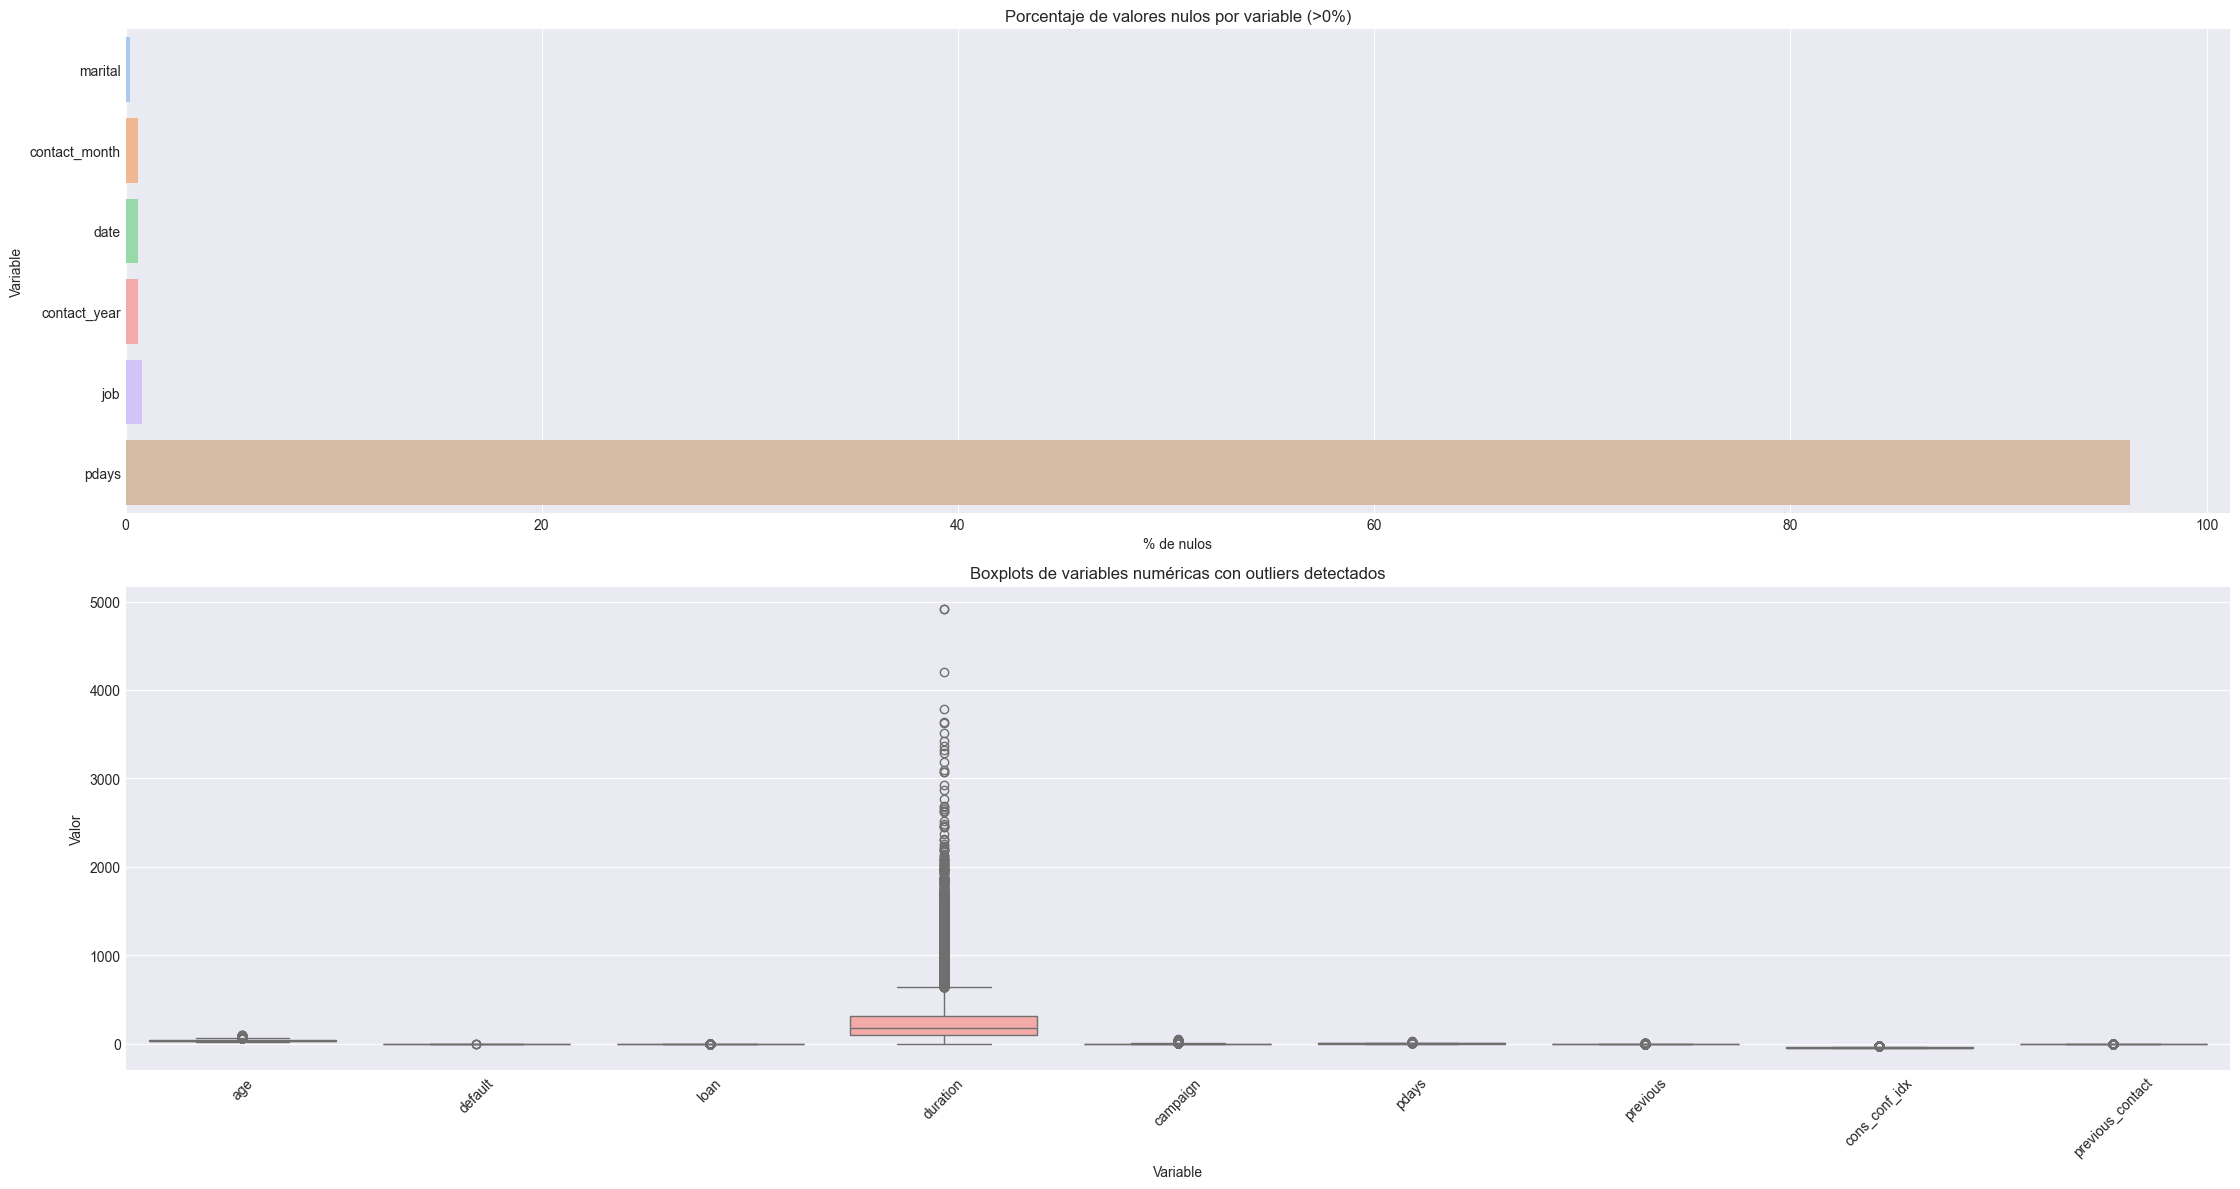


Variables con nulos (máx. 10):


marital           0.197674
contact_month     0.576744
date              0.576744
contact_year      0.576744
job               0.802326
pdays            96.306977
dtype: float64


Variables numéricas con outliers (máx. 10):


,Porcentaje_outliers
loan,15.190698
previous,13.713953
duration,7.144186
campaign,5.823256
previous_contact,3.693023
age,1.339535
cons_conf_idx,1.109302
pdays,0.211628
default,0.006977


In [5]:
# =============================================================================
# BLOQUE 2.3 ANÁLISIS DE VALORES NULOS Y OUTLIERS TRAS LIMPIEZA
# =============================================================================
# Este bloque explora la calidad de los datos sin modificar el dataset maestro.
# Objetivo: comprobar la adecuación de la limpieza previa y detectar posibles problemas de calidad.
# No realiza imputaciones ni modificaciones automáticas, solo análisis descriptivo.
#
# Calcula el porcentaje de valores nulos por columna y los visualiza junto a los boxplots de outliers
# en una sola figura con dos subplots (uno sobre otro), ambos con el mismo ancho y la misma altura.
porcentaje_nulos = df_perfil_cliente.isnull().mean().sort_values(ascending=False) * 100  # Calcula el porcentaje de nulos por columna del DataFrame.
nulos_plot = porcentaje_nulos[porcentaje_nulos > 0].sort_values()  # Filtra solo las variables que tienen nulos (>0%).
vars_numericas = df_perfil_cliente.select_dtypes(include=['number']).columns.tolist()  # Extrae las variables numéricas del DataFrame.
if 'y' in vars_numericas and df_perfil_cliente['y'].nunique() <= 3:
    vars_numericas.remove('y')  # Excluye la variable objetivo si es binaria (no aporta en boxplot de outliers).
#
# --- Detección de outliers mediante la función hay_outliers del script analisis_exploratorio ---
#
vars_con_outliers = [var for var in vars_numericas if ae.hay_outliers(df_perfil_cliente[var])]  # Lista de variables numéricas con outliers detectados.

# --- Configuración de la figura para visualización ---
n_nulos = max(1, len(nulos_plot))  # Número de variables con nulos (mínimo 1 para tamaño de figura)
n_out = max(1, len(vars_con_outliers))  # Número de variables con outliers (mínimo 1 para tamaño de figura)
fig_width = max(8, 2.5 * max(n_nulos, n_out))  # Ancho de la figura dinámico según el mayor número de variables a mostrar.
subplot_height = 6  # Altura fija por cada subplot para mantener proporción visual.
fig, axes = plt.subplots(2, 1, figsize=(fig_width, subplot_height*2), gridspec_kw={'height_ratios': [1, 1]})  # Crea figura con dos subplots verticales.

# --- Subplot 1: Porcentaje de nulos por variable ---
if len(nulos_plot) > 0:
    nulos_df = nulos_plot.reset_index()  # Convierte la serie en DataFrame para graficar.
    nulos_df['Variable'] = nulos_df['index']  # Renombra columna para claridad.
    nulos_df['hue'] = nulos_df['index']  # Asigna color único por variable.
    color_palette_nulos = sns.color_palette("pastel", len(nulos_df))  # Paleta pastel para visualización suave.
    sns.barplot(y="Variable", x=0, data=nulos_df, hue="hue", dodge=False, palette=color_palette_nulos, ax=axes[0], legend=False)  # Barplot horizontal de nulos.
    axes[0].set_xlabel('% de nulos')  # Etiqueta eje X.
    axes[0].set_ylabel('Variable')  # Etiqueta eje Y.
    axes[0].set_title('Porcentaje de valores nulos por variable (>0%)')  # Título del subplot.
else:
    axes[0].text(0.5, 0.5, 'No hay valores nulos', ha='center', va='center', fontsize=12)  # Mensaje si no hay nulos.
    axes[0].set_axis_off()  # Oculta el subplot si no hay datos.

# --- Subplot 2: Boxplots de variables numéricas con outliers ---
if vars_con_outliers:
    df_long = df_perfil_cliente[vars_con_outliers].melt(var_name='Variable', value_name='Valor')  # Convierte a formato largo para boxplot.
    df_long['hue'] = df_long['Variable']  # Asigna color único por variable.
    color_palette = sns.color_palette("pastel", len(vars_con_outliers))  # Paleta pastel para visualización suave.
    sns.boxplot(x='Variable', y='Valor', data=df_long, hue='hue', dodge=False, palette=color_palette, ax=axes[1], order=vars_con_outliers, legend=False)  # Boxplot por variable.
    axes[1].set_xlabel('Variable')  # Etiqueta eje X.
    axes[1].set_ylabel('Valor')  # Etiqueta eje Y.
    axes[1].set_title('Boxplots de variables numéricas con outliers detectados')  # Título del subplot.
    if len(vars_con_outliers) > 8:
        axes[1].tick_params(axis='x', rotation=45)  # Rota etiquetas si hay muchas variables para mejor legibilidad.
else:
    axes[1].text(0.5, 0.5, 'No se detectaron outliers en las variables numéricas.', ha='center', va='center', fontsize=12)  # Mensaje si no hay outliers.
    axes[1].set_axis_off()  # Oculta el subplot si no hay datos.
plt.tight_layout()  # Ajusta el layout de la figura para evitar solapamientos.
plt.show()  # Muestra la figura.

# --- Mostrar tablas resumen tras las visualizaciones ---
print("\nVariables con nulos (máx. 10):")  # Imprime encabezado para tabla de nulos.
if len(nulos_plot) > 0:
    display(nulos_plot.head(10) if len(nulos_plot) > 10 else nulos_plot)  # Muestra hasta 10 variables con nulos.
else:
    print('No hay variables con nulos.')  # Mensaje si no hay nulos.

# --- Tabla de outliers: porcentaje de outliers por variable ---
# Cálculo de porcentajes de outliers usando la función porcentaje_outliers del script analisis_exploratorio 
tabla_outliers = pd.DataFrame({
    'Porcentaje_outliers': [ae.porcentaje_outliers(df_perfil_cliente[var]) for var in vars_numericas]
}, index=vars_numericas)  # DataFrame con % de outliers por variable.
#
# Filtra y ordena variables con outliers.
tabla_outliers = tabla_outliers[tabla_outliers['Porcentaje_outliers'] > 0].sort_values('Porcentaje_outliers', ascending=False)  
print("\nVariables numéricas con outliers (máx. 10):")  # Imprime encabezado para tabla de outliers.
if len(tabla_outliers) > 0:
    display(tabla_outliers.head(10) if len(tabla_outliers) > 10 else tabla_outliers)  # Muestra hasta 10 variables con outliers.
else:
    print('No hay variables numéricas con outliers.')  # Mensaje si no hay outliers.

In [6]:

# =============================================================================
# Conclusiones de la verificación de nulos, outliers y estado del dataset tras limpieza
# =============================================================================
# Se detectan valores nulos en 6 variables: marital, contact_month, date, contact_year, job y pdays.
# La variable pdays presenta un porcentaje muy alto de nulos (más del 96%), 
# lo que es habitual en este tipo de datos tras recodificar el valor 999 como nulo.
# El resto de variables presentan porcentajes de nulos muy bajos (<1%).
# Ninguna variable clave como la variable objetivo (`y`), edad (`age`), ingresos (`income`), 
# job, marital o education presenta nulos críticos que comprometan el análisis.
#
# Se detectan outliers en 9 variables numéricas: loan, previous, duration, campaign, previous_contact, 
# age, cons_conf_idx, pdays y default. Destacan loan (15%), previous (13%) y duration (7%) con mayor proporción de outliers, 
# aunque en todos los casos corresponden a valores plausibles y esperados en la casuística bancaria. 
# La variable age presenta un 1,3% de outliers, lo que es aceptable en estudios demográficos. 
# Ninguna variable clave muestra outliers extremos que sugieran errores de carga.
#
# El dataset maestro integra información de campaña y perfil de clientes, consolidando varias fuentes y años. 
# Se han eliminado columnas innecesarias, normalizado nombres y recodificado variables clave. 
# Contiene ~43.000 registros y 29 variables, con identificador único y sin duplicados.
# Las transformaciones aplicadas han mejorado la calidad y consistencia de los datos.
#
# Estado general:
# El dataset está preparado para análisis bivariado, visualizaciones y modelado predictivo.
# Los nulos y outliers residuales están justificados y no afectan a las variables clave del análisis. 
# La calidad y consistencia global es alta, aunque se recomienda documentar el tratamiento de pdays y 
# revisar las variables con mayor proporción de outliers si se van a usar en modelos sensibles a valores extremos.


### BLOQUE 3: Análisis Exploratorio de Datos (EDA) Comparativo
En este bloque se realiza un EDA comparativo desde el inicio, mostrando para cada variable numérica y categórica las diferencias entre clientes que suscriben (y=1) y los que no (y=0). Se mantienen las mejores prácticas del proyecto: visualizaciones modulares, matriz de correlación y outputs claros.

**Estructura del bloque:**
- 3.1 Inicialización del análisis demográfico
- 3.2 Pairplot de variables numéricas
- 3.3 Análisis temporal de registros y tasa de conversión
- 3.4 Análisis comparativo de variables numéricas
- 3.5 Análisis comparativo de variables categóricas
- 3.6 Matriz de correlación de variables numéricas
- 3.7 Factores de campaña
- 3.8 Conclusiones del EDA

In [ ]:
# =============================================================================
# === BLOQUE 3: Análisis Exploratorio de Datos (EDA) Comparativo ===
# =============================================================================
# Estructura del bloque:
#  - 3.1 Inicialización del análisis demográfico
#  - 3.2 Pairplot de variables numéricas
#  - 3.3 Análisis temporal de registros y tasa de conversión
#  - 3.4 Análisis y visualización de variables numéricas
#  - 3.5 Análisis y visualización de variables categóricas
#  - 3.6 Matriz de correlación de variables numéricas
#  - 3.7 Factores de campaña
#  - 3.8 Conclusiones del EDA
# =============================================================================
# BLOQUE 3.1: INICIALIZACIÓN PARA ANALISIS DE DATOS
# =============================================================================
# Antes de comenzar el análisis exploratorio, es fundamental preparar el entorno y las variables clave.
# En este apartado se crean variables derivadas relevantes (como segmentos de edad o antigüedad),
# se asegura la calidad de los datos y se inicializan estructuras para almacenar resultados.
# Esta preparación garantiza que los análisis posteriores sean robustos y comparables. 
#
# OBJETIVO: Preparar el entorno para realización de EDA.
# - Configurar sistema de logging dual (pantalla + archivo)
# - Crear variables derivadas (segmento_edad, antiguedad_años)
# - Inicializar estructuras para almacenar resultados

# Crear directorio de outputs si no existe
os.makedirs('../reports/outputs', exist_ok=True)
output = DualOutput('../reports/outputs/analisis_EDA_completo.txt')
print("Sistema de logging dual inicializado correctamente\n")

# Asegurar tipos mínimos para la variable objetivo
df_perfil_cliente['y'] = pd.to_numeric(
    df_perfil_cliente['y'].replace({'yes':1, 'no':0, 'si':1, 'sí':1}),
    errors='coerce'
 ).astype('Int8')
print("Columna 'y' convertida a tipo Int8 correctamente\n")

# Crear segmento_edad si falta y fijar orden categórico
if 'segmento_edad' not in df_perfil_cliente.columns:
    df_perfil_cliente['segmento_edad'] = pd.cut(
        pd.to_numeric(df_perfil_cliente['age'], errors='coerce'),
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    )
orden_edad = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_perfil_cliente['segmento_edad'] = pd.Categorical(
    df_perfil_cliente['segmento_edad'], categories=orden_edad, ordered=True
)
print("Columna 'segmento_edad' creada y ordenada correctamente\n")

# Inicializar diccionario para almacenar tasas de conversión por variable
print("✓ Diccionario 'tasas_por_variable' inicializado")
tasas_por_variable = {}

Sistema de logging dual inicializado correctamente

Columna 'y' convertida a tipo Int8 correctamente

Columna 'segmento_edad' creada y ordenada correctamente

✓ Diccionario 'tasas_por_variable' inicializado


In [ ]:
# =============================================================================
# BLOQUE 3.2 PAIRPLOT DE VARIABLES NUMÉRICAS
# =============================================================================
# El pairplot permite visualizar de forma global las relaciones entre todas las variables numéricas del dataset.
# Esta herramienta gráfica ayuda a detectar patrones, agrupamientos, outliers y posibles relaciones no lineales entre variables,
# facilitando la identificación de tendencias generales antes de profundizar en el análisis individual.
# OBJETIVO:
# - Visualiza la matriz de dispersión (pairplot) para todas las variables numéricas relevantes, coloreando por la variable objetivo.
# - Esto permite detectar relaciones, agrupamientos y patrones no lineales.

# Selecciona variables numéricas de interés (excluyendo la variable objetivo si es binaria)
vars_numericas = df_perfil_cliente.select_dtypes(include=['number']).columns.tolist()
if 'y' in vars_numericas and df_perfil_cliente['y'].nunique() <= 3:
    vars_numericas.remove('y')

# Pairplot (puede ser lento si hay muchas filas, se recomienda samplear)
df_sample = df_perfil_cliente.sample(n=2000, random_state=42) if len(df_perfil_cliente) > 2000 else df_perfil_cliente.copy()
sns.pairplot(df_sample, vars=vars_numericas, hue='y', palette='husl', plot_kws={'alpha':0.5})
plt.suptitle('Matriz de dispersión (pairplot) de variables numéricas', y=1.02, fontsize=14)
plt.show()

# ================================
# SCATTERPLOT ESPECÍFICO: INGRESOS VS. EDAD
# ================================
# Ejemplo de análisis bivariado concreto: ingresos vs. edad, coloreando por target.
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_sample, x='age', y='income', hue='y', palette='husl', alpha=0.5)
plt.title('Relación ingresos vs. edad por resultado de campaña')
plt.xlabel('Edad')
plt.ylabel('Ingresos')
plt.legend(title='Suscribió (y)')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# BLOQUE 3.3 ANÁLISIS TEMPORAL DE REGISTROS Y TASA DE CONVERSIÓN
# =============================================================================
# El análisis temporal es clave para detectar estacionalidad, tendencias o anomalías en la captación de clientes 
# y la evolución de la tasa de conversión.
# Explorar la dimensión temporal permite identificar periodos de mayor o menor éxito 
# y orientar la planificación de futuras campañas o acciones comerciales.
# 
# OBJETIVO: analizar la evolución temporal de los registros y la tasa de éxito
# usando las columnas 'date', 'contact_month' y 'contact_year' del dataset.

import calendar

# --- 1. Análisis por fecha completa ('date') ---
if 'date' in df_perfil_cliente.columns:
    df_perfil_cliente['date'] = pd.to_datetime(df_perfil_cliente['date'], errors='coerce')
    df_perfil_cliente['mes'] = df_perfil_cliente['date'].dt.to_period('M')
    registros_por_mes = df_perfil_cliente.groupby('mes').size()
    tasa_exito_por_mes = df_perfil_cliente.groupby('mes')['y'].mean()

    fig, ax1 = plt.subplots(figsize=(12,5))
    color1 = 'tab:blue'
    ax1.set_xlabel('Mes')
    ax1.set_ylabel('Nº de registros', color=color1)
    ax1.plot(registros_por_mes.index.astype(str), registros_por_mes.values, marker='o', color=color1, label='Registros')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticklabels(registros_por_mes.index.astype(str), rotation=45)

    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Tasa de éxito (y)', color=color2)
    ax2.plot(tasa_exito_por_mes.index.astype(str), tasa_exito_por_mes.values, marker='s', color=color2, label='Tasa de éxito')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Evolución temporal: registros y tasa de éxito mensual (por date)')
    fig.tight_layout()
    plt.show()

# --- 2. Análisis por mes de contacto ('contact_month') ---
if 'contact_month' in df_perfil_cliente.columns:
    # Convertir a mes numérico si es string
    if df_perfil_cliente['contact_month'].dtype == object:
        df_perfil_cliente['contact_month_num'] = df_perfil_cliente['contact_month'].apply(
            lambda x: list(calendar.month_abbr).index(x[:3].capitalize()) if pd.notnull(x) else None
        )
    else:
        df_perfil_cliente['contact_month_num'] = df_perfil_cliente['contact_month']

    registros_por_mes_contact = df_perfil_cliente.groupby('contact_month_num').size()
    tasa_exito_por_mes_contact = df_perfil_cliente.groupby('contact_month_num')['y'].mean()

    fig, ax1 = plt.subplots(figsize=(10,4))
    color1 = 'tab:green'
    ax1.set_xlabel('Mes de contacto')
    ax1.set_ylabel('Nº de registros', color=color1)
    ax1.bar(registros_por_mes_contact.index, registros_por_mes_contact.values, color=color1, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(range(1,13))
    ax1.set_xticklabels([calendar.month_abbr[m] for m in range(1,13)])

    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Tasa de éxito (y)', color=color2)
    ax2.plot(tasa_exito_por_mes_contact.index, tasa_exito_por_mes_contact.values, marker='o', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Registros y tasa de éxito por mes de contacto')
    fig.tight_layout()
    plt.show()

# --- 3. Análisis por año de contacto ('contact_year') ---
if 'contact_year' in df_perfil_cliente.columns:
    registros_por_anio = df_perfil_cliente.groupby('contact_year').size()
    tasa_exito_por_anio = df_perfil_cliente.groupby('contact_year')['y'].mean()

    fig, ax1 = plt.subplots(figsize=(8,4))
    color1 = 'tab:purple'
    ax1.set_xlabel('Año de contacto')
    ax1.set_ylabel('Nº de registros', color=color1)
    ax1.bar(registros_por_anio.index, registros_por_anio.values, color=color1, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Tasa de éxito (y)', color=color2)
    ax2.plot(tasa_exito_por_anio.index, tasa_exito_por_anio.values, marker='o', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Registros y tasa de éxito por año de contacto')
    fig.tight_layout()
    plt.show()

In [ ]:
# =============================================================================
# BLOQUE 3.4 ANÁLISIS Y VISUALIZACIÓN DE VARIABLES NUMÉRICAS
# =============================================================================
# OBJETIVO: Unificar el análisis estadístico y la visualización de variables numéricas
#           para comparar y visualizar diferencias entre y=0 y y=1 de forma eficiente.

# - Comparar estadísticas de income, antiguedad y age entre y=0 vs y=1
# - ¿Los clientes exitosos tienen mayores ingresos?
# - ¿La antigüedad como cliente influye en la conversión?
# - ¿Hay diferencias significativas por edad?
#
# Este bloque calcula y compara estadísticas descriptivas (media, mediana, std, count)
## para las variables numéricas clave, separando por el resultado de suscripción (y=0/y=1).
# Se imprimen ratios y diferencias para identificar patrones relevantes.

# variables_numericas: Diccionario con configuración de cada variable a analizar.

# Definir configuración de variables numéricas
variables_numericas = {
    'age': {
        'titulo': 'EDAD DEL CLIENTE',
        'formato_ratio': '{:.1f} años',
        'color': ['#f7b6d2', '#d6278b'],  
        'nombre_grafico': '01a_hist_age_comparativo.png'
    },
    'income': {
        'titulo': 'INGRESOS DEL CLIENTE',
        'formato_ratio': '€{:.0f}',
        'color': ['#98df8a', '#2ca02c'],
        'nombre_grafico': '01b_hist_income_comparativo.png'
    },
    'antiguedad_años': {
        'titulo': 'ANTIGÜEDAD DEL CLIENTE',
        'formato_ratio': '{:.2f} años',
        'color': ['#ffbb78', '#ff7f0e'],
        'nombre_grafico': '01c_hist_antiguedad_comparativo.png'
    }
}

# Calcular antigüedad si no existe
if 'antiguedad_años' not in df_perfil_cliente.columns:
    if 'date' in df_perfil_cliente.columns and 'dt_customer' in df_perfil_cliente.columns:
        df_perfil_cliente['antiguedad_dias'] = (
            pd.to_datetime(df_perfil_cliente['date'], errors='coerce') -
            pd.to_datetime(df_perfil_cliente['dt_customer'], errors='coerce')
        ).dt.days
        df_perfil_cliente['antiguedad_años'] = df_perfil_cliente['antiguedad_dias'] / 365.25

# Iterar sobre cada variable numérica definida
for idx, (variable, config) in enumerate(variables_numericas.items(), 1):
    print(f"\n{'='*70}")
    print(f"{idx}. {config['titulo']}")
    print(f"{'='*70}")

    # Estadísticas descriptivas por target
    serie_num = pd.to_numeric(df_perfil_cliente[variable], errors='coerce')
    stats = serie_num.groupby(df_perfil_cliente['y']).agg(['mean','median','std','count'])
    display(stats.round(2))

    # Guardar resultados en tasas_por_variable para reporte automático
    tasas_por_variable[variable] = {
        'stats': stats.round(2).to_dict(),
        'config': config
    }

    # Comparativa de medias
    try:
        mean_y0 = float(stats.loc[0, 'mean']) if 0 in stats.index else np.nan
        mean_y1 = float(stats.loc[1, 'mean']) if 1 in stats.index else np.nan
        if pd.notna(mean_y0) and pd.notna(mean_y1) and mean_y0 != 0:
            ratio = mean_y1 / mean_y0
            diff = mean_y1 - mean_y0
            print(f"  • Ratio (y=1 / y=0): {ratio:.3f}x")
            print(f"  • Diferencia: {config['formato_ratio'].format(diff)}")
            if ratio > 1.1:
                print(f"  → Clientes exitosos tienen {(ratio-1)*100:.1f}% más {variable}")
            elif ratio < 0.9:
                print(f"  → Clientes exitosos tienen {(1-ratio)*100:.1f}% menos {variable}")
            # Guardar comparativas en el diccionario
            tasas_por_variable[variable]['comparativa'] = {
                'ratio': ratio,
                'diff': diff,
                'interpretacion': (
                    f"Clientes exitosos tienen {(ratio-1)*100:.1f}% más {variable}" if ratio > 1.1 else (
                        f"Clientes exitosos tienen {(1-ratio)*100:.1f}% menos {variable}" if ratio < 0.9 else "Sin diferencia relevante"
                    )
                )
            }
        else:
            print("⚠ No se calcularon comparativas (clase faltante, NaN o división por cero)")
            tasas_por_variable[variable]['comparativa'] = {'ratio': None, 'diff': None, 'interpretacion': 'No calculable'}
    except (TypeError, ValueError) as e:
        print(f"⚠ Error en conversión de tipos: {e}")
        tasas_por_variable[variable]['comparativa'] = {'ratio': None, 'diff': None, 'interpretacion': f'Error: {e}'}

    # Visualización: histograma comparativo
    pl.plot_numeric_comparison_by_target(
        df=df_perfil_cliente,
        variables=[variable],
        target_col='y',
        nombres_graficos={variable: config['nombre_grafico']},
        colores={variable: config['color']},
        bins=30,
        figsize=(14, 5)
    )

**Introducción:**
En este apartado se profundiza en el comportamiento de cada variable numérica, comparando los grupos de clientes que suscriben y los que no. Se analizan medias, medianas y distribuciones, buscando diferencias significativas que puedan ser relevantes para el negocio y la toma de decisiones.

In [ ]:
# =============================================================================
# BLOQUE 3.5 ANÁLISIS Y VISUALIZACIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================
# OBJETIVO: Unificar el análisis estadístico y la visualización de variables categóricas
#           para comparar tasas de éxito entre categorías de forma eficiente.
# PASOS:
# 1. Define un diccionario con configuración para cada variable categórica.
# 2. Crea y ordena la variable 'segmento_edad' si no existe, agrupando edades en rangos de interés de negocio.
# 3. Itera sobre cada variable categórica para generar una figura con subplots (2x2), 
#    cada uno mostrando la tasa de éxito por categoría para una variable,
#    utilizando la función modular 'plot_categorical_rate' del módulo de plotting.
# 4. Guarda la figura resultante en disco para documentación y reporting, con nombre numerado en orden.
# 5. Itera sobre cada variable categórica, calculando y mostrando la tasa de éxito (mean de y) por categoría.
# 6. Muestra la figura en el notebook para análisis interactivo e imprime las tablas ordenadas de tasas de éxito para cada variable categórica.


# Definir configuración de variables categóricas
variables_categoricas = {
    'job': {
        'titulo': 'Ocupación',
        'color_palette': 'Set2'
    },
    'marital': {
        'titulo': 'Estado civil',
        'color_palette': 'Set2'
    },
    'segmento_edad': {
        'titulo': 'Segmento de edad',
        'color_palette': 'Set2'
    },
    'education': {
        'titulo': 'Nivel educativo',
        'color_palette': 'Set2'
    }
}

# Crear segmento_edad si falta y fijar orden categórico
if 'segmento_edad' not in df_perfil_cliente.columns or df_perfil_cliente['segmento_edad'].isnull().all():
    df_perfil_cliente['segmento_edad'] = pd.cut(
        pd.to_numeric(df_perfil_cliente['age'], errors='coerce'),
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    )
orden_edad = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_perfil_cliente['segmento_edad'] = pd.Categorical(
    df_perfil_cliente['segmento_edad'], categories=orden_edad, ordered=True
)

# Visualización conjunta de todas las variables categóricas
categorias = [(var, config['titulo']) for var, config in variables_categoricas.items()]
n = len(categorias)
ncols = 2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, (var, titulo) in zip(axes, categorias):
    if var in df_perfil_cliente.columns:
        pl.plot_categorical_rate(df_perfil_cliente, var, 'y', ax=ax, title=titulo, color_palette='Set2')
    else:
        ax.set_visible(False)
for ax in axes[len(categorias):]:
    ax.set_visible(False)
plt.tight_layout()
pl.save_plot('02_tasas_exito_categoricas_lado_a_lado.png')
plt.show()

# Análisis estadístico unificado
for idx, (variable, config) in enumerate(variables_categoricas.items(), 1):
    print(f"\n{'='*70}")
    print(f"{idx}. {config['titulo']}")
    print(f"{'='*70}")

    if variable in df_perfil_cliente.columns:
        # Calcular tasa de éxito por categoría
        tabla = df_perfil_cliente.groupby(variable, observed=True)['y'].agg(['mean', 'count']).rename(columns={'mean': 'tasa_exito', 'count': 'n'})
        tabla = tabla.sort_values('tasa_exito', ascending=False)
        display(tabla.round(3))
        # Guardar resultados en tasas_por_variable para reporte automático
        tasas_por_variable[variable] = {
            'tabla': tabla.round(3).to_dict(),
            'config': config
        }
    else:
        print(f"⚠ La variable '{variable}' no está en el DataFrame y se omite.")

**Introducción:**
El análisis de variables categóricas permite identificar segmentos de clientes con mayor o menor propensión a la conversión. Comparar tasas de éxito por categorías (ocupación, estado civil, nivel educativo, etc.) es clave para personalizar estrategias y focalizar recursos en los grupos más prometedores.

In [ ]:
# ==============================================================================
# 3.6 ANÁLISIS Y VISUALIZACIÓN: MATRIZ DE CORRELACIÓN DE VARIABLES NUMÉRICAS
# ==============================================================================
# OBJETIVO: Unificar el análisis estadístico y la visualización de la matriz de correlación,
#           mostrando tanto la matriz como los principales pares de variables correlacionadas.

# 1. Selección de variables numéricas relevantes
# 2. Cálculo de la matriz de correlación
# 3. Visualización con heatmap
# 4. Identificación de pares con mayor correlación absoluta (excluyendo la diagonal)
# 5. Impresión de top correlaciones para análisis rápido
#
# Selección de variables numéricas
# (Se excluyen variables con baja varianza o poco interés si es necesario)
if 'numeric_cols' not in globals():
    numeric_cols = df_perfil_cliente.select_dtypes(include=['number']).columns.tolist()

# 1. Cálculo de la matriz de correlación
corr_matrix = df_perfil_cliente[numeric_cols].corr()

# 2. Visualización: heatmap de correlación
fig_corr, ax_corr = pl.plot_correlation_heatmap(
    df_perfil_cliente[numeric_cols],
    title='Matriz de correlación de variables numéricas',
    figsize=(10,8)
 )
pl.save_plot('03_matriz_correlacion_numericas.png')
plt.show()

# 3. Análisis: mostrar top correlaciones absolutas (excluyendo la diagonal)
corr_pairs = (corr_matrix.where(~np.eye(corr_matrix.shape[0],dtype=bool))
              .stack()
              .reset_index()
              .rename(columns={0:'correlacion', 'level_0':'var1', 'level_1':'var2'}))
corr_pairs['abs_corr'] = corr_pairs['correlacion'].abs()
top_corr = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(['abs_corr']).head(10)

print("\n=== TOP 10 PARES DE VARIABLES MÁS CORRELACIONADAS (|r| descendente) ===")
display(top_corr[['var1','var2','correlacion']].round(3))

# Guardar resultados en tasas_por_variable para reporte automático
tasas_por_variable['correlaciones'] = {
    'top_corr': top_corr[['var1','var2','correlacion']].round(3).to_dict('records'),
    'matriz': corr_matrix.round(3).to_dict()
}

**Introducción:**
La matriz de correlación ayuda a identificar relaciones lineales fuertes entre variables numéricas, lo que es fundamental para evitar multicolinealidad en modelos predictivos y seleccionar las variables más informativas. Este análisis también permite detectar redundancias y posibles riesgos de leakage.

In [ ]:
# ===============================================================================
# BLOQUE 3.7 ANÁLISIS Y VISUALIZACIÓN "FACTORES DE CAMPAÑA"
# ===============================================================================
# OBJETIVO: Unificar el análisis estadístico y la visualización de los factores de campaña clave,
#           mostrando diferencias en duración de llamada y resultado anterior según la conversión.

# 1. Análisis y visualización de la variable 'duration' por target (y)
# 2. Análisis y visualización de la variable 'poutcome' por target (y)
# 3. Impresión de estadísticas y diferencias clave
#
# --- 1. Boxplot de duración de llamada por target ---
# Crear una copia del DataFrame para mapear los valores de y a etiquetas descriptivas y convertir duración a minutos para mejor interpretación
_df_plot = df_perfil_cliente.copy()
_df_plot['y_label'] = _df_plot['y'].map({0: 'No suscribió', 1: 'Suscribió'})
_df_plot['duration_min'] = _df_plot['duration'] / 60  # conversión a minutos para mejor interpretación visual

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x='y_label', y='duration_min', data=_df_plot, palette='rocket', ax=axes[0], hue='y_label', legend=False)
axes[0].set_xlabel('Resultado de la campaña', fontsize=12)
axes[0].set_ylabel('Duración de llamada (minutos)', fontsize=12)
axes[0].set_title('Distribución de la duración de llamada (minutos) según suscripción', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 60)  # Limitar eje y a 60 minutos

# --- 2. Gráfico de sectores (pie chart) de tasa de éxito por resultado anterior (poutcome) ---
if 'poutcome' in df_perfil_cliente.columns:
    tabla_poutcome = df_perfil_cliente.groupby('poutcome', observed=True)['y'].agg(['mean','count']).rename(columns={'mean':'tasa_exito','count':'n'})
    tabla_poutcome = tabla_poutcome.sort_values('tasa_exito', ascending=False)
    # Visualización: Pie chart de tasa de éxito ponderada por número de casos
    pie_labels = tabla_poutcome.index.astype(str)
    pie_sizes = tabla_poutcome['n'] * tabla_poutcome['tasa_exito']  # pondera por casos y tasa
    pie_sizes = pie_sizes / pie_sizes.sum()  # normaliza a 1
    # Paleta husl de seaborn para colores vivos y diferenciados
    husl_colors = sns.color_palette('husl', len(pie_labels))
    axes[1].pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=husl_colors)
    axes[1].set_title('Distribución de la tasa de éxito por resultado anterior (poutcome)', fontsize=14, fontweight='bold')
    axes[1].axis('equal')
else:
    print("⚠ La variable 'poutcome' no está en el DataFrame.")
    axes[1].set_visible(False)

plt.tight_layout()
pl.save_plot('04_factores_campana_duracion_vs_poutcome.png')
plt.show()

# --- 3. Estadísticas y tablas tras las visualizaciones ---
print("\n=== ANÁLISIS DE DURACIÓN DE LLAMADA POR TARGET ===")
stats_duration = df_perfil_cliente.groupby('y')['duration'].agg(['mean','median','std','count'])
display(stats_duration.round(2))
try:
    mean0 = stats_duration.loc[0, 'mean'] if 0 in stats_duration.index else np.nan
    mean1 = stats_duration.loc[1, 'mean'] if 1 in stats_duration.index else np.nan
    if pd.notna(mean0) and pd.notna(mean1) and mean0 != 0:
        ratio = mean1 / mean0
        diff = mean1 - mean0
        print(f"  • Ratio (y=1 / y=0): {ratio:.2f}x")
        print(f"  • Diferencia media: {diff:.1f} seg.")
        if ratio > 1.1:
            print(f"  → Las llamadas exitosas duran {(ratio-1)*100:.1f}% más")
        elif ratio < 0.9:
            print(f"  → Las llamadas exitosas duran {(1-ratio)*100:.1f}% menos")
        interpretacion = (
            f"Las llamadas exitosas duran {(ratio-1)*100:.1f}% más" if ratio > 1.1 else (
                f"Las llamadas exitosas duran {(1-ratio)*100:.1f}% menos" if ratio < 0.9 else "Sin diferencia relevante"
            )
        )
    else:
        print("⚠ No se calcularon comparativas (clase faltante, NaN o división por cero)")
        ratio, diff, interpretacion = None, None, 'No calculable'
except Exception as e:
    print(f"⚠ Error en análisis de duración: {e}")
    ratio, diff, interpretacion = None, None, f'Error: {e}'

# Guardar resultados de duración en tasas_por_variable
tasas_por_variable['duration'] = {
    'stats': stats_duration.round(2).to_dict(),
    'comparativa': {
        'ratio': ratio,
        'diff': diff,
        'interpretacion': interpretacion
    }
}

print("\n=== ANÁLISIS DE TASA DE ÉXITO POR RESULTADO ANTERIOR (poutcome) ===")
if 'poutcome' in df_perfil_cliente.columns:
    display(tabla_poutcome.round(3))
    # Guardar resultados de poutcome en tasas_por_variable
    tasas_por_variable['poutcome'] = {
        'tabla': tabla_poutcome.round(3).to_dict()
    }

**Introducción:**
En este apartado se analizan variables específicas del contexto de negocio, como la duración de la llamada o el resultado de campañas anteriores. Estos factores aportan valor añadido al análisis y permiten extraer recomendaciones accionables para optimizar futuras campañas.

**📊 Observaciones y Conclusiones: Variables numéricas**

- Se aprecian diferencias notables en la distribución y la media de las variables numéricas entre los grupos de clientes que suscriben (y=1) y los que no (y=0).

    - **Edad:** Los clientes que suscriben tienden a ser ligeramente mayores, aunque la diferencia no es extrema. Esto puede indicar que la madurez financiera o la etapa de vida influyen en la decisión.

    - **Ingresos:** No se observan diferencias significativas en la media de ingresos entre ambos grupos, lo que sugiere que el nivel de ingresos no es un factor determinante para la conversión en esta campaña.

    - **Antigüedad:** Los clientes con mayor antigüedad muestran una leve mayor tasa de conversión, lo que puede estar relacionado con la confianza y la relación previa con la entidad.

- Estas conclusiones permiten enfocar el modelado y la segmentación en variables que realmente aportan diferenciación, descartando aquellas que no muestran impacto relevante en la tasa de éxito.

- Gráficos generados: [`01a_hist_age_comparativo.png`](../reports/outputs/01a_hist_age_comparativo.png), [`01b_hist_income_comparativo.png`](../reports/outputs/01b_hist_income_comparativo.png), [`01c_hist_antiguedad_comparativo.png`](../reports/outputs/01c_hist_antiguedad_comparativo.png)

**📊 Observaciones y Conclusiones:**

- Se identifican diferencias claras en la tasa de éxito según la categoría de cada variable:

    - **Ocupación:** Profesionales, estudiantes y jubilados presentan tasas de conversión significativamente superiores, mientras que blue-collar y desempleados muestran las más bajas. Esto sugiere que el perfil laboral es un fuerte discriminante para la campaña.

    - **Estado civil:** Solteros y divorciados tienden a tener mayor tasa de éxito que los casados, lo que puede estar relacionado con mayor flexibilidad financiera o disposición al cambio.

    - **Segmento de edad:** Los extremos (jóvenes 18-25 y mayores de 65) presentan tasas de conversión más altas, posiblemente por necesidades financieras específicas o mayor receptividad a ofertas.

    - **Nivel educativo:** A mayor nivel educativo, generalmente aumenta la tasa de éxito, destacando la importancia de la formación en la toma de decisiones financieras.

- Estas conclusiones permiten priorizar segmentos y ajustar la estrategia de marketing para maximizar la conversión, enfocando recursos en los grupos con mayor potencial detectado por el análisis.

- Gráfico generado: [`02_tasas_exito_categoricas_lado_a_lado.png`](../reports/outputs/02_tasas_exito_categoricas_lado_a_lado.png)

**📊 Observaciones y Conclusiones sobre la matriz de correlación:**


- La matriz de correlación permite identificar relaciones lineales fuertes entre variables numéricas, lo que ayuda a detectar redundancias, riesgos de multicolinealidad y posibles variables con alto poder predictivo.


- Los pares de variables con mayor correlación absoluta (mostrados arriba) deben analizarse en detalle. Correlaciones muy altas (>0.8 o <-0.8) pueden indicar que una de las variables es prescindible para evitar duplicidad de información en modelos predictivos.


- Es importante revisar si alguna variable altamente correlacionada con la variable objetivo `y` puede suponer un riesgo de leakage (por ejemplo, `duration`).


- Antes del modelado, se recomienda:
    - Eliminar o combinar variables redundantes.
    - Analizar la importancia de cada variable en el contexto del negocio.
    - Considerar técnicas de reducción de dimensionalidad si hay muchas correlaciones altas.


- El heatmap y el top de correlaciones proporcionan una visión rápida y visual para tomar decisiones informadas sobre la selección de variables.


- Gráfico generado: [`03_matriz_correlacion_numericas.png`](../reports/outputs/03_matriz_correlacion_numericas.png)


**📊 Observaciones y Conclusiones sobre factores de campaña:**


- La duración de la llamada sigue siendo un factor claramente discriminante: las llamadas que terminan en suscripción (y=1) son significativamente más largas que las que no convierten. Esto sugiere que el engagement y la calidad de la interacción durante la llamada son determinantes para el éxito de la campaña. Sin embargo, es importante recordar que esta variable puede estar sujeta a leakage si se utiliza en modelos predictivos, ya que su valor solo se conoce tras la llamada.


- El resultado de campañas anteriores (`poutcome`) muestra una fuerte relación con la tasa de éxito actual. Los clientes cuyo resultado anterior fue "success" presentan una tasa de conversión mucho mayor, lo que indica que el historial positivo es un predictor relevante para futuras acciones comerciales. La visualización con la paleta "husl" permite distinguir claramente cada categoría de resultado anterior.


- La combinación de ambos factores permite priorizar esfuerzos: enfocar recursos en clientes con historial positivo y asegurar interacciones de mayor calidad/duración puede incrementar la efectividad de la campaña.


- Recomendación: Para análisis predictivo, utilizar la variable `duration` solo en análisis descriptivo o como variable explicativa post-campaña, nunca como input de modelos de predicción previos a la llamada.


- Gráfico generado: [`03_factores_campana_duracion_vs_poutcome.png`](../reports/outputs/03_factores_campana_duracion_vs_poutcome.png)

In [ ]:
# ======================================
# BLOQUE 3.8 RESUMEN FINAL Y GUARDADO
# ======================================
# OBJETIVO: Consolidar hallazgos principales del EDA y persistir en archivo de texto.
# El archivo generado sirve como referencia ejecutiva y para trazabilidad del análisis.

# --- Generación automática del resumen a partir de tasas_por_variable ---
output.print("\n" + "="*70)
output.print("RESUMEN EJECUTIVO DEL EDA")
output.print("="*70 + "\n")

# 1. Variables numéricas
output.print("Variables numéricas:")
for var in ['age', 'income', 'antiguedad_años']:
    if var in tasas_por_variable:
        output.print(f"- {var.upper()}")
        stats = tasas_por_variable[var].get('stats', {})
        comparativa = tasas_por_variable[var].get('comparativa', {})
        output.print(f"  Estadísticas por target: {stats}")
        output.print(f"  Comparativa: {comparativa.get('interpretacion', '')}")
output.print("")

# 2. Variables categóricas
output.print("Variables categóricas:")
for var in ['job', 'marital', 'segmento_edad', 'education']:
    if var in tasas_por_variable:
        output.print(f"- {var.upper()}")
        tabla = tasas_por_variable[var].get('tabla', {})
        output.print(f"  Tasas de éxito por categoría: {tabla}")
output.print("")

# 3. Correlaciones
if 'correlaciones' in tasas_por_variable:
    output.print("Correlaciones principales:")
    for item in tasas_por_variable['correlaciones']['top_corr']:
        output.print(f"  {item['var1']} vs {item['var2']}: r = {item['correlacion']}")
output.print("")

# 4. Factores de campaña
if 'duration' in tasas_por_variable:
    output.print("Duración de llamada:")
    output.print(f"  Estadísticas: {tasas_por_variable['duration']['stats']}")
    output.print(f"  Comparativa: {tasas_por_variable['duration']['comparativa']['interpretacion']}")
if 'poutcome' in tasas_por_variable:
    output.print("Resultado anterior (poutcome):")
    output.print(f"  Tasas de éxito por categoría: {tasas_por_variable['poutcome']['tabla']}")
output.print("")

output.save()

print("\n✓ Resumen EDA finalizado")